# Import Libraries & Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("datasets/Pricing_Data.csv")   # replace with your file name
# Basic view
df.head()


,SKU,Product_description,Product Role,Country_of_Origin,FBA Fee,Storage Fee,Handling_Cost,Cost,Current_Price,Minimum_Acceptable_Margin_%,Target_Gross_Margin_%
0,MN-01,Rectangle Tray -14 x 10 Inch - Pk of 25,Core,India,$15.11,$0.44,$0.75,$16.00,$38.90,20%,35%
1,MN-02,Rectangle Tray -12x10 - Pk of 25,Core,India,$13.55,$0.30,$0.75,$12.00,$33.90,20%,35%
2,MN-03,Oval Tray -15x10 Inch - Pk of 25,Core,India,$13.94,$0.34,$0.75,$15.00,$34.90,20%,35%
3,MN-04,Oval Tray - 13x9 Inch - pk of 25,Core,India,$12.89,$0.30,$0.75,$12.00,$29.90,20%,35%
4,MN-05,Christmas Tray - 17x12 Inch - Pk of 5,Seasonal,India,$11.80,$0.22,$0.75,$13.00,$21.90,25%,45%


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   SKU                          50 non-null     object
 1   Product_description          50 non-null     object
 2   Product Role                 50 non-null     object
 3   Country_of_Origin            50 non-null     object
 4   FBA Fee                      50 non-null     object
 5   Storage Fee                  50 non-null     object
 6   Handling_Cost                49 non-null     object
 7   Cost                         50 non-null     object
 8   Current_Price                50 non-null     object
 9   Minimum_Acceptable_Margin_%  50 non-null     object
 10  Target_Gross_Margin_%        50 non-null     object
dtypes: object(11)
memory usage: 4.4+ KB


In [4]:
df.shape

(50, 11)

In [5]:
df.isnull().sum()

SKU                            0
Product_description            0
Product Role                   0
Country_of_Origin              0
FBA Fee                        0
Storage Fee                    0
Handling_Cost                  1
Cost                           0
Current_Price                  0
Minimum_Acceptable_Margin_%    0
Target_Gross_Margin_%          0
dtype: int64

In [6]:
# Missing values count
df.isnull().sum()

# Missing values percentage
(df.isnull().sum() / len(df)) * 100


SKU                            0.0
Product_description            0.0
Product Role                   0.0
Country_of_Origin              0.0
FBA Fee                        0.0
Storage Fee                    0.0
Handling_Cost                  2.0
Cost                           0.0
Current_Price                  0.0
Minimum_Acceptable_Margin_%    0.0
Target_Gross_Margin_%          0.0
dtype: float64

In [7]:
df.columns

Index(['SKU', 'Product_description', 'Product Role', 'Country_of_Origin',
       'FBA Fee', 'Storage Fee', 'Handling_Cost', 'Cost', 'Current_Price',
       'Minimum_Acceptable_Margin_%', 'Target_Gross_Margin_%'],
      dtype='object')

In [8]:
cols_money = ['FBA Fee', 'Storage Fee', 'Handling_Cost', 'Cost', 'Current_Price']

for col in cols_money:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)   # just drop $
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [9]:
df['Handling_Cost'] = df['Handling_Cost'].fillna(0)               # or median, or drop rows

In [10]:
df.isnull().sum()

SKU                            0
Product_description            0
Product Role                   0
Country_of_Origin              0
FBA Fee                        0
Storage Fee                    0
Handling_Cost                  0
Cost                           0
Current_Price                  0
Minimum_Acceptable_Margin_%    0
Target_Gross_Margin_%          0
dtype: int64

In [11]:
df.head()

,SKU,Product_description,Product Role,Country_of_Origin,FBA Fee,Storage Fee,Handling_Cost,Cost,Current_Price,Minimum_Acceptable_Margin_%,Target_Gross_Margin_%
0,MN-01,Rectangle Tray -14 x 10 Inch - Pk of 25,Core,India,15.11,0.44,0.75,16.0,38.9,20%,35%
1,MN-02,Rectangle Tray -12x10 - Pk of 25,Core,India,13.55,0.30,0.75,12.0,33.9,20%,35%
2,MN-03,Oval Tray -15x10 Inch - Pk of 25,Core,India,13.94,0.34,0.75,15.0,34.9,20%,35%
3,MN-04,Oval Tray - 13x9 Inch - pk of 25,Core,India,12.89,0.30,0.75,12.0,29.9,20%,35%
4,MN-05,Christmas Tray - 17x12 Inch - Pk of 5,Seasonal,India,11.80,0.22,0.75,13.0,21.9,25%,45%


## Convert Columns to Correct Data Types

# MULTIPLE CATEGORICAL COLUMNS

In [12]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [13]:
cat_cols

Index(['SKU', 'Product_description', 'Product Role', 'Country_of_Origin',
       'Minimum_Acceptable_Margin_%', 'Target_Gross_Margin_%'],
      dtype='object')

# NUMERICAL COLUMNS

In [14]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [20]:
num_cols

Index(['FBA Fee', 'Storage Fee', 'Handling_Cost', 'Cost', 'Current_Price'], dtype='object')

# Check Duplicate Records

In [15]:
# Number of duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()


# Statistical Summary

In [16]:
# Numerical summary
df.describe()

# Categorical summary
df.describe(include='object')


,SKU,Product_description,Product Role,Country_of_Origin,Minimum_Acceptable_Margin_%,Target_Gross_Margin_%
count,50,50,50,50,50,50
unique,50,50,2,1,2,2
top,MN-01,Rectangle Tray -14 x 10 Inch - Pk of 25,Core,India,20%,35%
freq,1,1,46,50,46,46


# Univariate Analysis

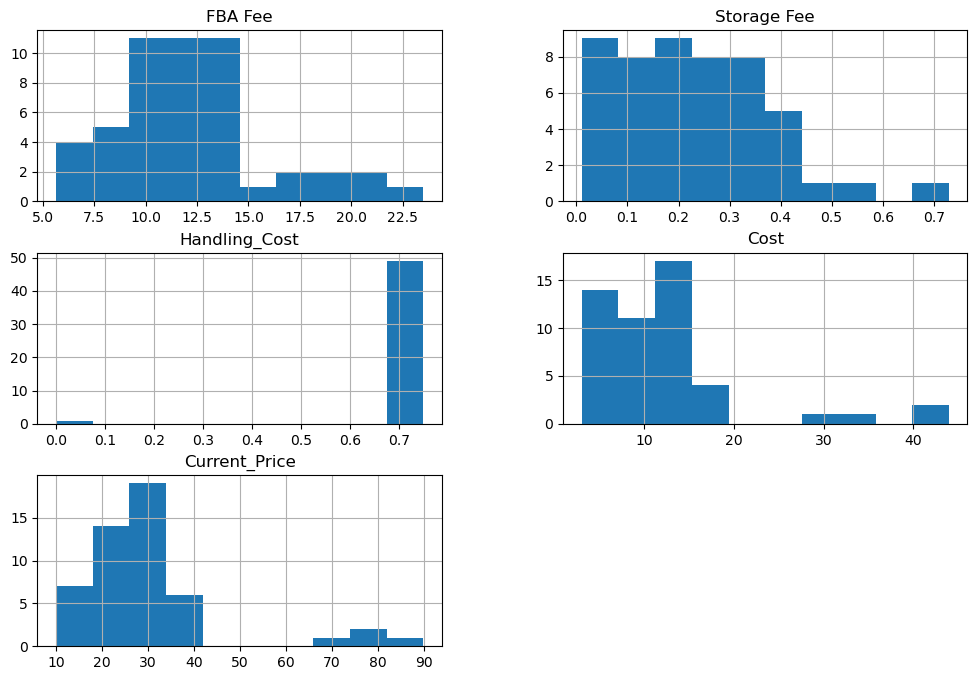

In [17]:
df.hist(figsize=(12, 8))
plt.show()

# Categorical Columns

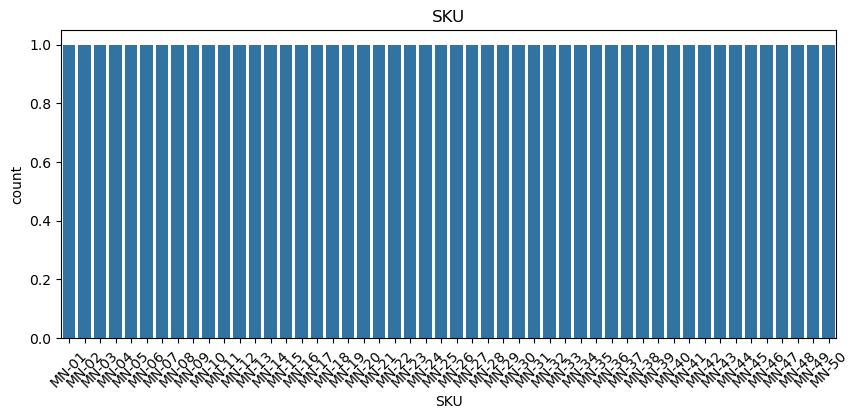

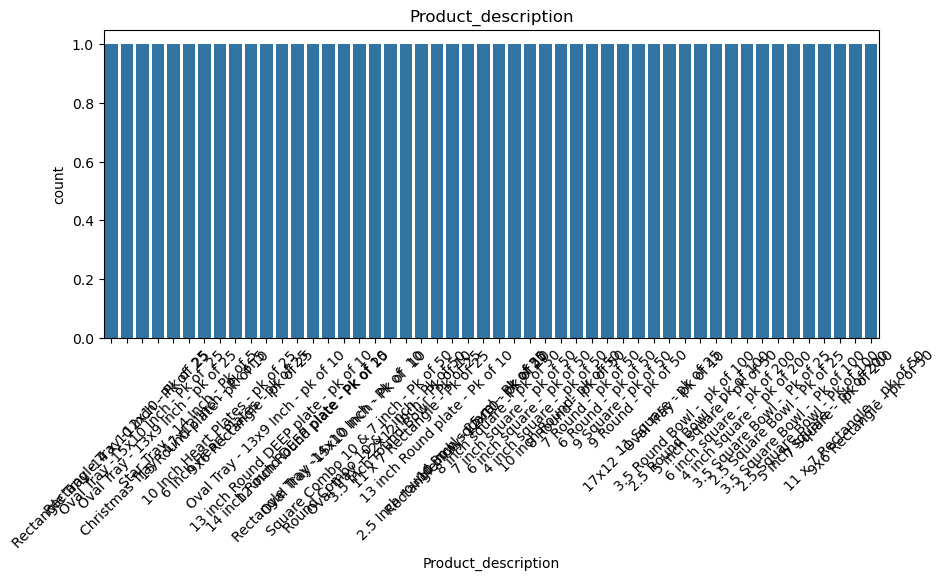

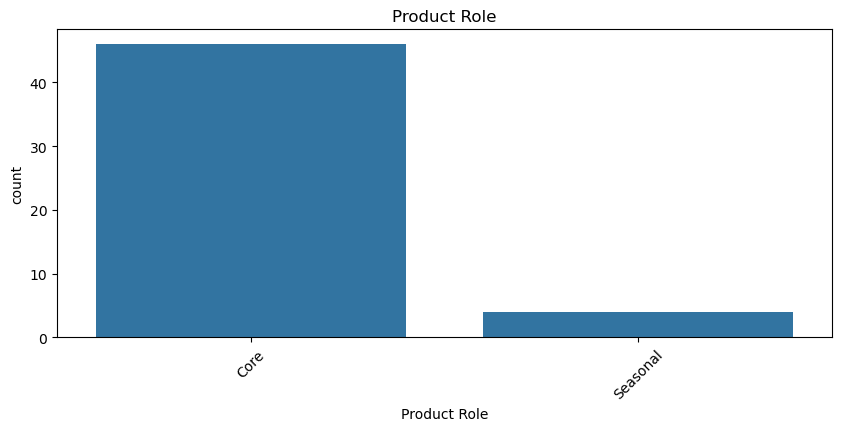

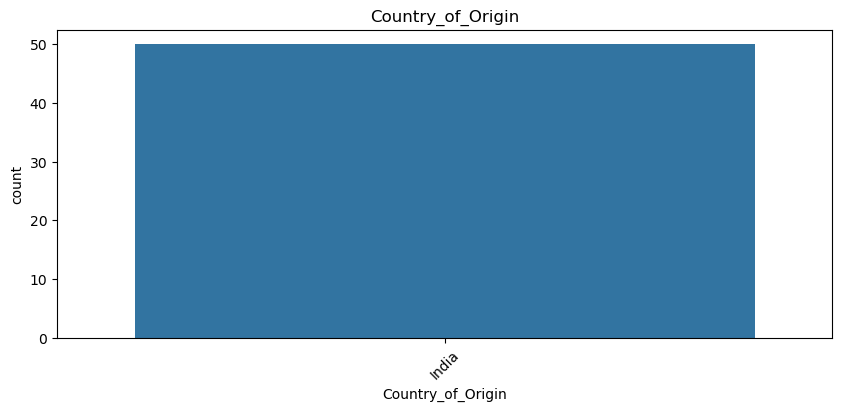

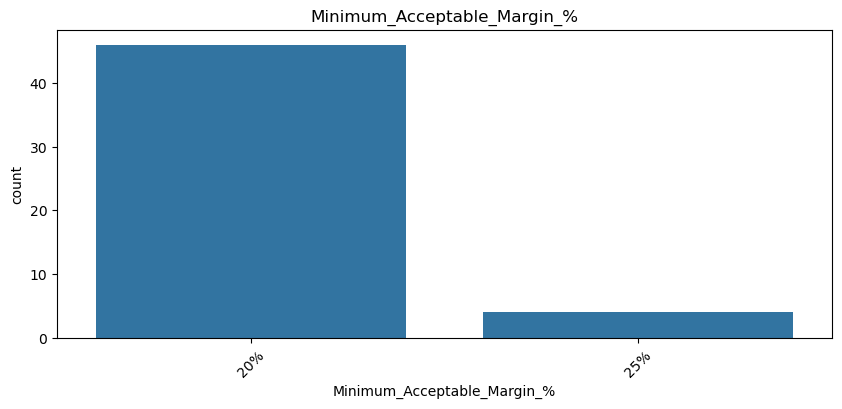

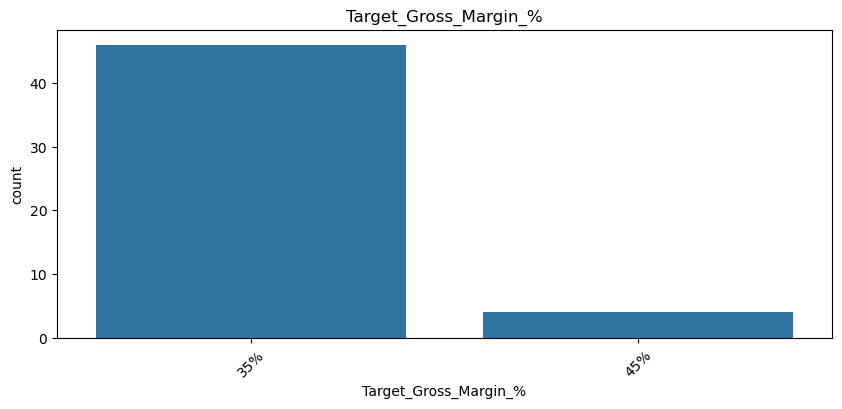

In [21]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()


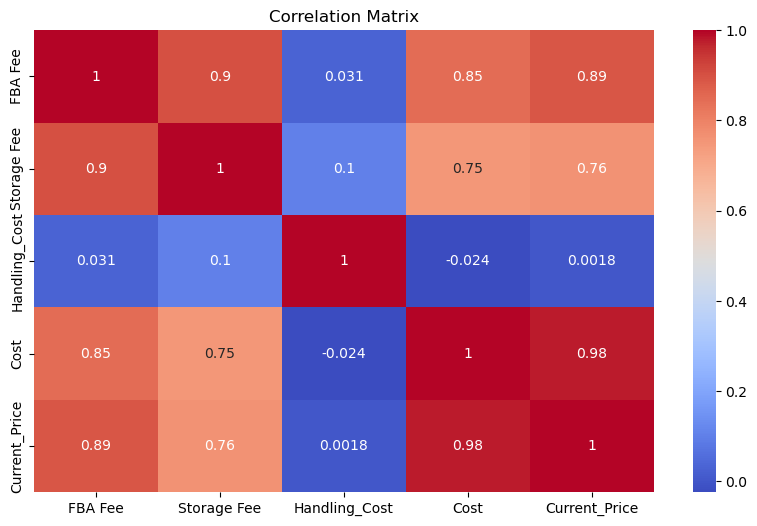

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
